In [12]:
# Install necessary libraries
!pip install ngboost bayesian-optimization

In [13]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from ngboost import NGBRegressor
from ngboost.distns import Normal
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt

In [14]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
            'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour', 'vessel_type']
target = 'TravelTime_seconds'

<ipython-input-14-6b9069eb52ab>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [15]:
# Split data into train and test sets
train_data, test_data = train_test_split(data[features + [target]], test_size=0.2, random_state=42)

# Separate features and target
X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# Check for NaN values in the dataset
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in X_test:", X_test.isnull().sum().sum())

NaN values in X_train: 14
NaN values in X_test: 1


In [11]:
# Bayesian Optimization for Hyperparameter Tuning
def ngboost_hyperopt(n_estimators, learning_rate, minibatch_frac):
    """
    Objective function for Bayesian Optimization.
    """
    # Convert hyperparameters to appropriate types
    n_estimators = int(n_estimators)

    # Initialize and train the NGBoost model
    model = NGBRegressor(
        Dist=Normal,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        minibatch_frac=minibatch_frac,
        random_state=42,
        verbose=0
    )

    # Fit the model
    model.fit(X_train, y_train)

    # Predict on the validation set (using a subset of the training data for faster evaluation)
    y_pred = model.predict(X_test)

    # Use negative MAE as the objective (Bayesian Optimization maximizes the objective)
    return -mean_absolute_error(y_test, y_pred)

# Define the parameter bounds for Bayesian Optimization
param_bounds = {
    'n_estimators': (100, 200),  # Number of boosting iterations
    'learning_rate': (0.01, 0.1),  # Learning rate
    'minibatch_frac': (0.1, 1.0),  # Fraction of data to use for each iteration
}

# Initialize Bayesian Optimization
optimizer = BayesianOptimization(
    f=ngboost_hyperopt,
    pbounds=param_bounds,
    random_state=42
)

# Perform optimization
optimizer.maximize(init_points=5, n_iter=10)  # Adjust init_points and n_iter as needed

# Print the best hyperparameters
best_params = optimizer.max['params']
print("Best Hyperparameters from Bayesian Optimization:")
print(best_params)

|   iter    |  target   | learni... | miniba... | n_esti... |
-------------------------------------------------------------
| 1         | -1.048e+0 | 0.04371   | 0.9556    | 173.2     |
| 2         | -1.156e+0 | 0.06388   | 0.2404    | 115.6     |
| 3         | -1.721e+0 | 0.01523   | 0.8796    | 160.1     |
| 4         | -1.341e+0 | 0.07373   | 0.1185    | 197.0     |
| 5         | -1.171e+0 | 0.08492   | 0.2911    | 118.2     |
| 6         | -9.982e+0 | 0.0745    | 0.9825    | 180.5     |
| 7         | -2.758e+0 | 0.01571   | 0.9682    | 100.0     |
| 8         | -1.444e+0 | 0.02224   | 0.1219    | 136.9     |
| 9         | -1.233e+0 | 0.02288   | 0.1631    | 188.2     |
| 10        | -1.101e+0 | 0.05321   | 0.9693    | 147.3     |
| 11        | -1.26e+04 | 0.03077   | 0.9741    | 127.1     |
| 12        | -1.231e+0 | 0.07711   | 0.103     | 176.9     |
| 13        | -1.292e+0 | 0.05129   | 0.113     | 168.2     |
| 14        | -1.526e+0 | 0.01794   | 0.1315    | 152.0     |
| 15    

In [19]:
# Check for NaN values in the dataset
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in X_test:", X_test.isnull().sum().sum())
print("NaN values in y_train:", y_train.isnull().sum())
print("NaN values in y_test:", y_test.isnull().sum())

# Handle NaN values in X_train and X_test
X_train = X_train.fillna(X_train.mean())  # Impute with mean
X_test = X_test.fillna(X_train.mean())  # Use training data mean to avoid data leakage

# Handle NaN values in y_train and y_test
y_train = y_train.fillna(y_train.mean())  # Impute with mean
y_test = y_test.fillna(y_train.mean())  # Use training data mean to avoid data leakage

# Verify that NaN values are handled
print("NaN values in X_train after handling:", X_train.isnull().sum().sum())
print("NaN values in X_test after handling:", X_test.isnull().sum().sum())
print("NaN values in y_train after handling:", y_train.isnull().sum())
print("NaN values in y_test after handling:", y_test.isnull().sum())

# Train the final model with the best hyperparameters
best_model = NGBRegressor(
    Dist=Normal,
    n_estimators=int(best_params['n_estimators']),
    learning_rate=best_params['learning_rate'],
    minibatch_frac=best_params['minibatch_frac'],
    random_state=42,
    verbose=100
)

# Fit the best model
best_model.fit(X_train, y_train)

# Predict on the test set
y_pred_best = best_model.predict(X_test)

# Evaluate the best model
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("\nBest Model Performance:")
print("Mean Absolute Error:", mae_best)
print("Mean Squared Error:", mse_best)
print("R-squared:", r2_best)

NaN values in X_train: 14
NaN values in X_test: 1
NaN values in y_train: 0
NaN values in y_test: 0
NaN values in X_train after handling: 0
NaN values in X_test after handling: 0
NaN values in y_train after handling: 0
NaN values in y_test after handling: 0
[iter 0] loss=14.2623 val_loss=0.0000 scale=1.0000 norm=235279.4876
[iter 100] loss=10.4038 val_loss=0.0000 scale=1.0000 norm=10419.0132

Best Model Performance:
Mean Absolute Error: 9975.027034760462
Mean Squared Error: 403573420.7834335
R-squared: 0.9970199226351534


In [23]:
# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(X, y, kf):
    mae_scores = []
    mse_scores = []
    r2_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train NGBoost model with best hyperparameters
        model = NGBRegressor(
            Dist=Normal,
            n_estimators=int(best_params['n_estimators']),
            learning_rate=best_params['learning_rate'],
            minibatch_frac=best_params['minibatch_frac'],
            random_state=42,
            verbose=0
        )
        model.fit(X_train, y_train)

        # Predict on the test set
        y_pred = model.predict(X_test)

        # Calculate metrics
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        mse_scores.append(mean_squared_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    return mae_scores, mse_scores, r2_scores

# Check for NaN values in the dataset
print("NaN values in features:", data[features].isnull().sum().sum())
print("NaN values in target:", data[target].isnull().sum())

# Handle NaN values in features and target
data[features] = data[features].fillna(data[features].mean())  # Impute with mean
data[target] = data[target].fillna(data[target].mean())  # Impute with mean

# Verify that NaN values are handled
print("NaN values in features after handling:", data[features].isnull().sum().sum())
print("NaN values in target after handling:", data[target].isnull().sum())

# Perform K-Fold Cross-Validation
mae_scores, mse_scores, r2_scores = evaluate_model(data[features], data[target], kf)

# Print results
print(f'MAE Scores: {mae_scores}')
print(f'MSE Scores: {mse_scores}')
print(f'R2 Scores: {r2_scores}')
print(f'Mean MAE: {sum(mae_scores)/len(mae_scores)}')
print(f'Mean MSE: {sum(mse_scores)/len(mse_scores)}')
print(f'Mean R2: {sum(r2_scores)/len(r2_scores)}')

NaN values in features: 15
NaN values in target: 0
NaN values in features after handling: 0
NaN values in target after handling: 0
MAE Scores: [9784.05801384367, 10090.185290639542, 9625.69075693696, 9826.304498681631, 10055.943010544137]
MSE Scores: [381985161.3079256, 526930045.31389606, 357337503.9335007, 397220304.8653437, 430978214.1924165]
R2 Scores: [0.9971793352230401, 0.996337958926171, 0.9975588825341029, 0.9970670209231303, 0.9970324556396625]
Mean MAE: 9876.436314129187
Mean MSE: 418890245.92261654
Mean R2: 0.9970351306492213


In [24]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the best model
ngboost_mape = mean_absolute_percentage_error(y_test, y_pred_best)
print(f"NGBoost MAPE: {ngboost_mape:.2f}%")

NGBoost MAPE: 3.01%


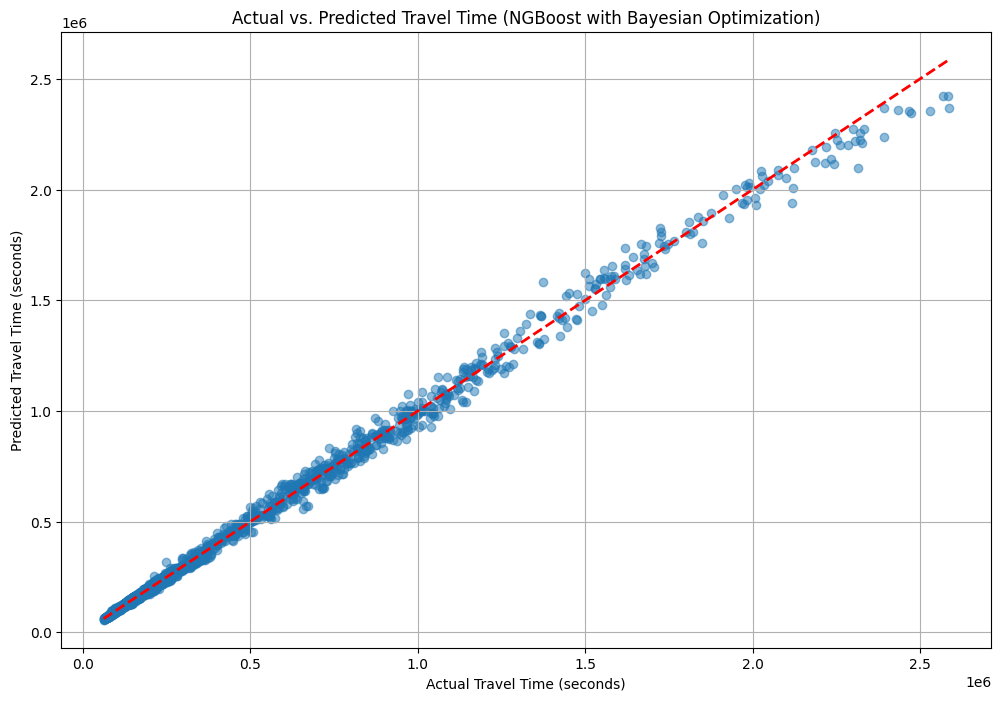

In [25]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (NGBoost with Bayesian Optimization)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

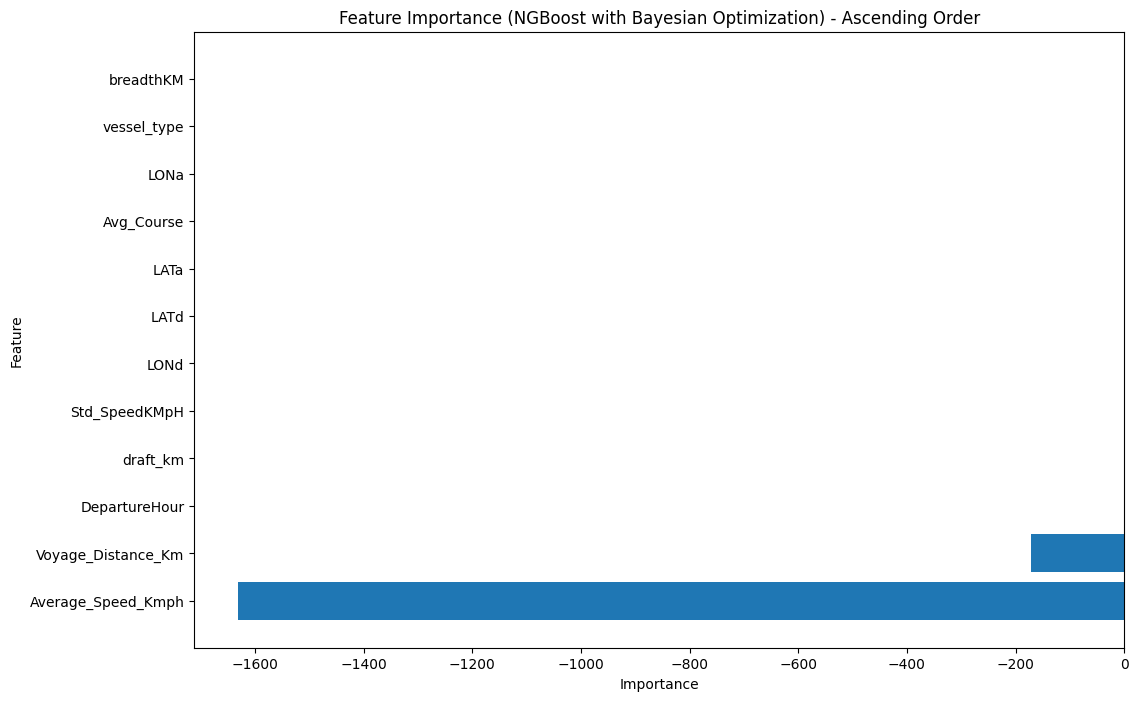

In [27]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Get feature importance scores
feature_importance = result.importances_mean
feature_names = X_train.columns

# Sort feature importance and feature names in ascending order
sorted_indices = np.argsort(feature_importance)  # Get indices for sorting
sorted_feature_importance = feature_importance[sorted_indices]  # Sort importance values
sorted_feature_names = feature_names[sorted_indices]  # Sort feature names

# Plot Feature Importance in ascending order
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names, sorted_feature_importance)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (NGBoost with Bayesian Optimization) - Ascending Order')
plt.show()